# A/B Testing Analysis: Website Layout Optimization
## Objective
To determine if the new page layout increases user conversion rates compared to the existing design.

## Methodology
1. **Experimental Design:** Pre-analysis for statistical power.
2. **Data Integrity:** Cleaning the dataset of inconsistent user records.
3. **statistical Testing:** Performing a Two-proportion z-test.
4. **Conclusion:** Data-driven business recommendations.

In [12]:
import statsmodels.stats.api as sms
import numpy as np

# Power analysis to ensure test validity 
effect_size = sms.proportion_effectsize(0.12, 0.14)
required_n = sms.NormalIndPower().solve_power(effect_size, power= 0.8, alpha=0.05, ratio=1)
print(f"Required Sample Size per Group: {int(np.ceil(required_n))}")

Required Sample Size per Group: 4433


In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm

df = pd.read_csv('ab_test.csv')

In [3]:
df.head(5)

,id,time,con_treat,page,converted
0,851104,11:48.6,control,old_page,0
1,804228,01:45.2,control,old_page,0
2,661590,55:06.2,treatment,new_page,0
3,853541,28:03.1,treatment,new_page,0
4,864975,52:26.2,control,old_page,1


In [5]:
# Check for users assigned to both groups
double_users = df.groupby('id')['con_treat'].nunique()
double_users = double_users[double_users > 1].index

# Remove those users from the dataset
df_clean = df[~df['id'].isin(double_users)]

print(f"Users with inconsistent group assignmemnt: {len(double_users)}")
print(f"Total rows after cleaning:{len(df_clean)}")

Users with inconsistent group assignmemnt: 1895
Total rows after cleaning:290688


In [6]:
# Calculate conversion rate by group
conversion_rates = df_clean.groupby('con_treat')['converted'].mean()

print("Conversion Rates by Group:")
print(conversion_rates)

Conversion Rates by Group:
con_treat
control      0.120345
treatment    0.118929
Name: converted, dtype: float64


In [7]:
from statsmodels.stats.proportion import proportions_ztest

# Preparing the data for Z-test
n_con = df_clean[df_clean['con_treat'] == 'control'].shape[0]
n_treat = df_clean[df_clean['con_treat'] == 'treatment'].shape[0]

success_con = df_clean[df_clean['con_treat'] == 'control']['converted'].sum()
success_treat = df_clean[df_clean['con_treat'] == 'treatment']['converted'].sum()

successes = np.array([success_con, success_treat])
nobs = np.array([n_con, n_treat])

# Running Z-test
z_stat, p_value = proportions_ztest(successes, nobs)

print(f"Z-statistic: {z_stat:.4f}")
print(f"P-value: {p_value:.4f}")


Z-statistic: 1.1765
P-value: 0.2394


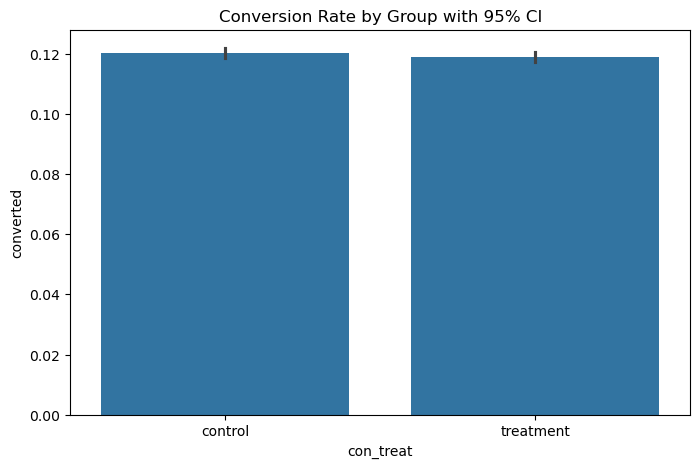

In [9]:
plt.figure(figsize=(8,5))
sns.barplot(x='con_treat', y='converted', data=df_clean, errorbar=('ci',95))
plt.title('Conversion Rate by Group with 95% CI')
plt.show()


### Conclusion & Recommendations
* **Statistical Significance:** The p-value of 0.2394 is greater thanthe standard threshold of 0.05.
Therefore, the observed difference in conversion rates between the control and treatrment group is not statistically significant.
* **Business Insight:** We do not have sufficient evidence to conclude that the new page design negatively impacts conversion. The variance observed is likely due to random noises.
* **Action Plan:** I recommend either extending the A/B test to collect more data to reach a definitive conclusion or iterating on the design to introduce more significant changesif we want to observe a measurable improvement.